In [1]:
import re
from bs4 import BeautifulSoup as bs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import umap
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from functions import compare_fradulent_vs_not

/Users/zhengchong/Desktop/GovTech THA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('./DataSet.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   title                17880 non-null  str  
 1   location             17534 non-null  str  
 2   department           6333 non-null   str  
 3   salary_range         2868 non-null   str  
 4   company_profile      14572 non-null  str  
 5   description          17880 non-null  str  
 6   requirements         15191 non-null  str  
 7   benefits             10684 non-null  str  
 8   telecommuting        17880 non-null  str  
 9   has_company_logo     17880 non-null  str  
 10  has_questions        17880 non-null  str  
 11  employment_type      14409 non-null  str  
 12  required_experience  10830 non-null  str  
 13  required_education   9775 non-null   str  
 14  industry             12977 non-null  str  
 15  function             11425 non-null  str  
 16  fraudulent           17880 non-nu

## Data Cleaning & Exporatory Data Analysis


In [4]:
# NA Values
df = (df
    .dropna(subset=['location']) # rationale is if no location shown, then it is ambiguous whether it is a legitimate job opening
    .dropna(subset=['employment_type', 'required_experience', 'required_education', 'industry', 'function'], how='all') # key information, if all missing in a row, drop
    )

df['required_education'] = df['required_education'].fillna('Unspecified')


In [5]:
# Splitting location columns
df[['country', 'region', 'city']] = df['location'].str.split(',', n=2, expand=True)

# Strip whitespace
df['country'] = df['country'].str.strip()
df['region'] = df['region'].str.strip()
df['city'] = df['city'].str.strip()

df = df.drop(columns=['location'])

In [6]:
# Looking at country, region and city
# keep country for simplicity

df = df.drop(columns=['region','city'])

In [7]:
# parsing html of company_profile
df['company_profile'] = df['company_profile'].apply(lambda x: bs(str(x), 'html.parser').get_text())
df['company_profile'] = df['company_profile'].str.replace('\n', ' ')

In [8]:
# parsing html of description
df['description'] = df['description'].apply(lambda x: bs(str(x), 'html.parser').get_text())
df['description'] = df['description'].str.replace('\n', ' ')

In [9]:
# parsing html of requirements
df['requirements'] = df['requirements'].apply(lambda x: bs(str(x), 'html.parser').get_text())
df['requirements'] = df['requirements'].str.replace('\n', ' ')

In [10]:
# parsing html of benefits
df['benefits'] = df['benefits'].apply(lambda x: bs(str(x), 'html.parser').get_text())
df['benefits'] = df['benefits'].str.replace('\n', ' ')

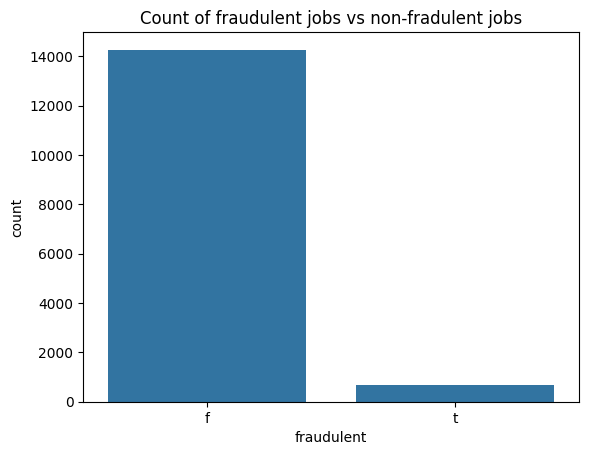

In [11]:
sns.countplot(data=df, x='fraudulent')
plt.title('Count of fraudulent jobs vs non-fradulent jobs')
plt.show()

Majority of the data belongs to non-fradulent jobs. To prevent our classification models from overfitting on the majority class. We will consider using a subset of the data where
in_balanced_dataset == 't' from now onwards

In [12]:
copy_df = (df.copy()
        .loc[df['in_balanced_dataset'] == 't']
        .drop(columns=['in_balanced_dataset'])
        .reset_index(drop=True)
)

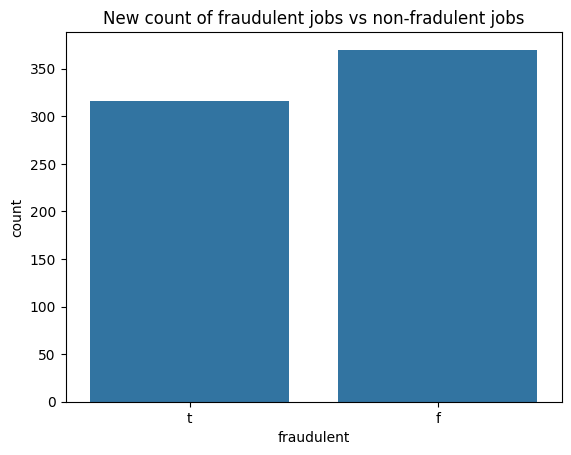

In [13]:
sns.countplot(data=copy_df, x='fraudulent')
plt.title('New count of fraudulent jobs vs non-fradulent jobs')
plt.show()

Although it looks more reasonably balanced with roughly a 50:50 split, the number of rows differ drastically from the original dataset. 

- Undersampling to 685 rows introduces high variance. Any small changes in the subset could significantly alter model performance
- The model trained on a 50:50 split may not reflect real-world distribution where fraud is rare (~5%), potentially leading to too many false alarms in production

Therefore, we will still stick with the original dataset.

In [14]:
df = df.drop(columns='in_balanced_dataset')

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 14939 entries, 0 to 17879
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   title                14939 non-null  str  
 1   department           5291 non-null   str  
 2   salary_range         2824 non-null   str  
 3   company_profile      14939 non-null  str  
 4   description          14939 non-null  str  
 5   requirements         14939 non-null  str  
 6   benefits             14939 non-null  str  
 7   telecommuting        14939 non-null  str  
 8   has_company_logo     14939 non-null  str  
 9   has_questions        14939 non-null  str  
 10  employment_type      14277 non-null  str  
 11  required_experience  10737 non-null  str  
 12  required_education   14939 non-null  str  
 13  industry             12879 non-null  str  
 14  function             11341 non-null  str  
 15  fraudulent           14939 non-null  str  
 16  country              14939 non-null  s

In [16]:
# Dropping department column as it has too many null values to make sense of it
df = df.drop(columns=['department'])

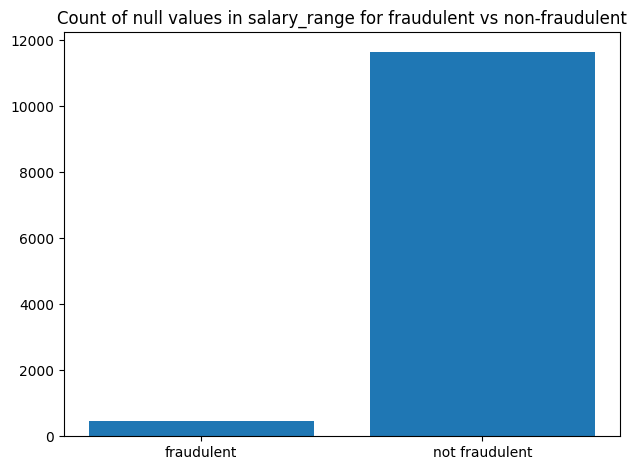

In [17]:
fradulent = df['fraudulent']=='t'
not_fradulent = df['fraudulent']=='f'

plt.bar(['fraudulent', 'not fraudulent'], [df.loc[fradulent,'salary_range'].isna().sum(), df.loc[not_fradulent,'salary_range'].isna().sum()])
plt.title('Count of null values in salary_range for fraudulent vs non-fraudulent')

plt.tight_layout()
plt.show()

count of null values in salary_range has a positive relationship with whether it is fraudulent/not fraudulent. Therefore, we will just replace null values in salary_range column with 'Unknown' despite there being many null values.

In [18]:
df['salary_range'] = df['salary_range'].fillna('Unknown')

KeyError: 'country'

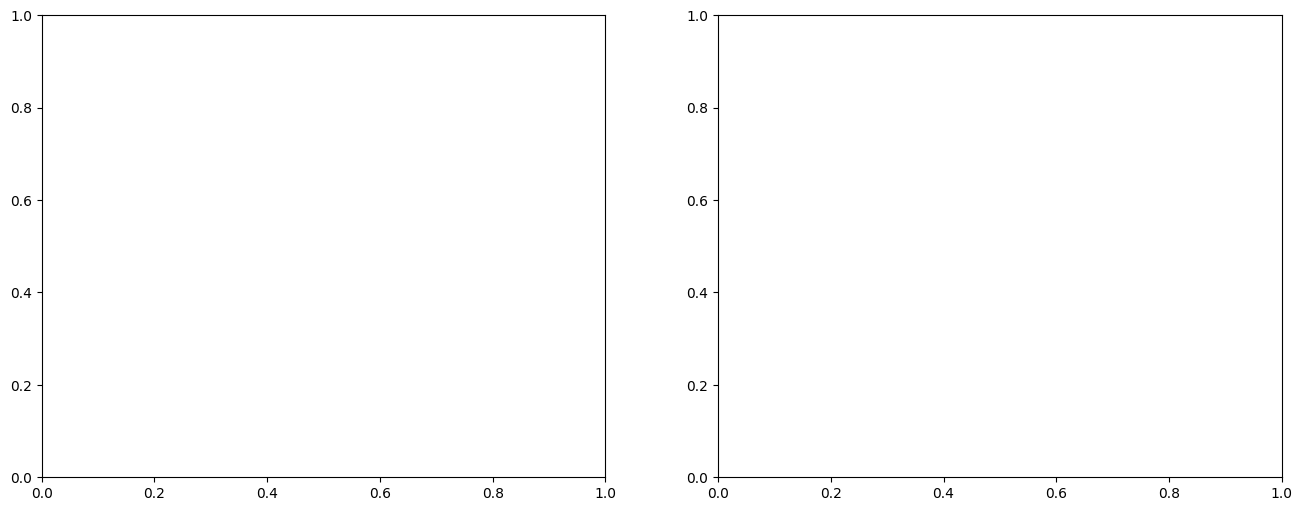

In [ ]:
compare_fradulent_vs_not(df, 'country')

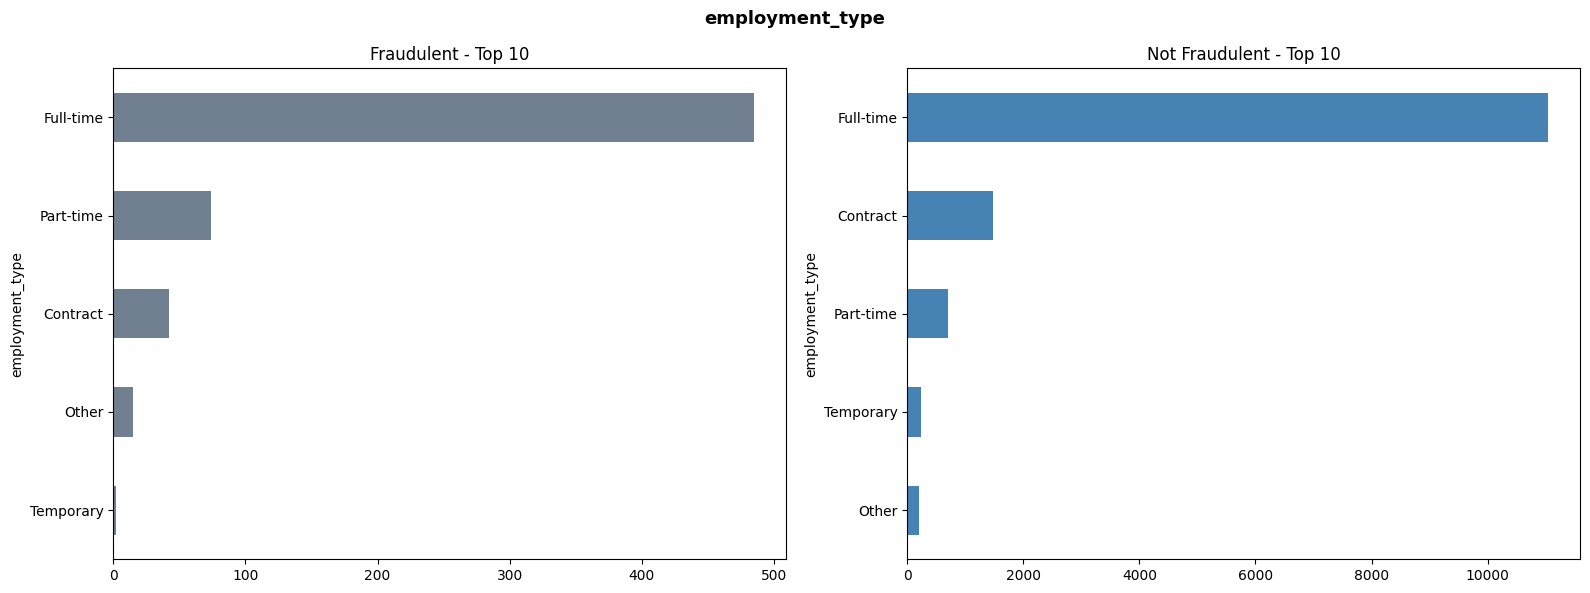

In [19]:
compare_fradulent_vs_not(df, 'employment_type')

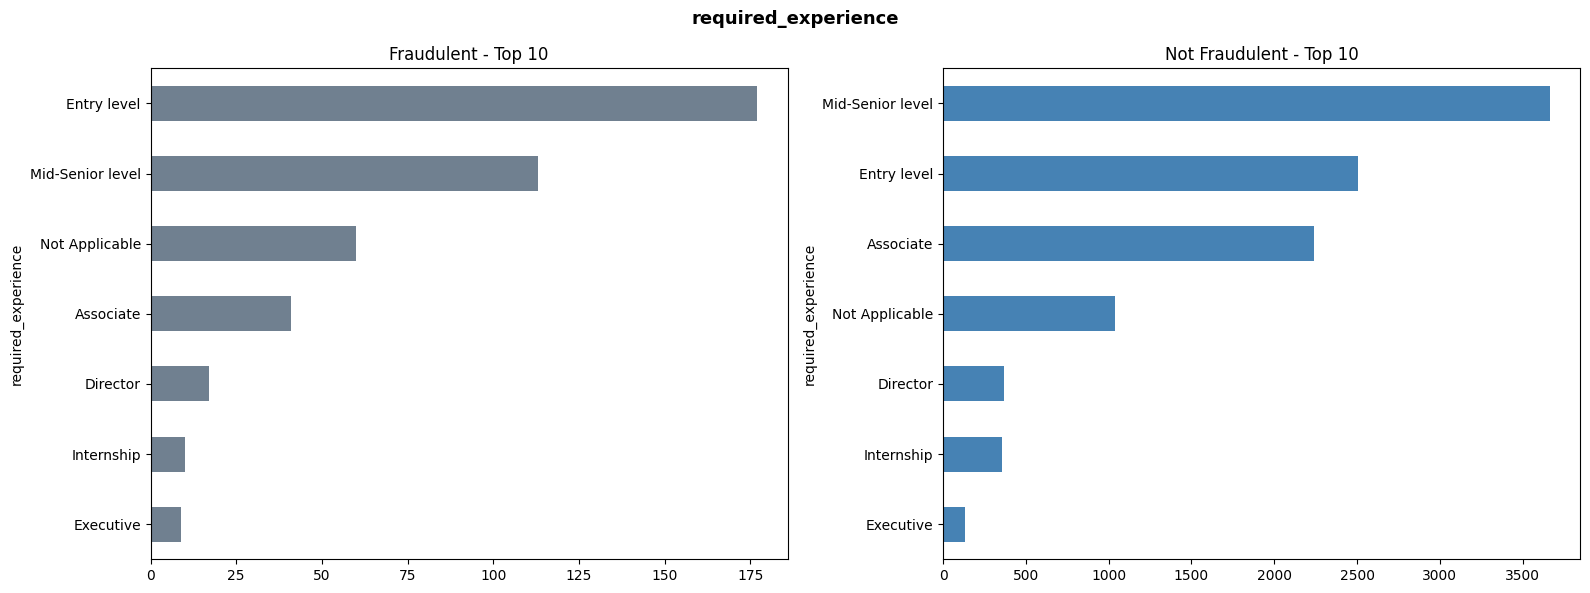

In [20]:
compare_fradulent_vs_not(df, 'required_experience')

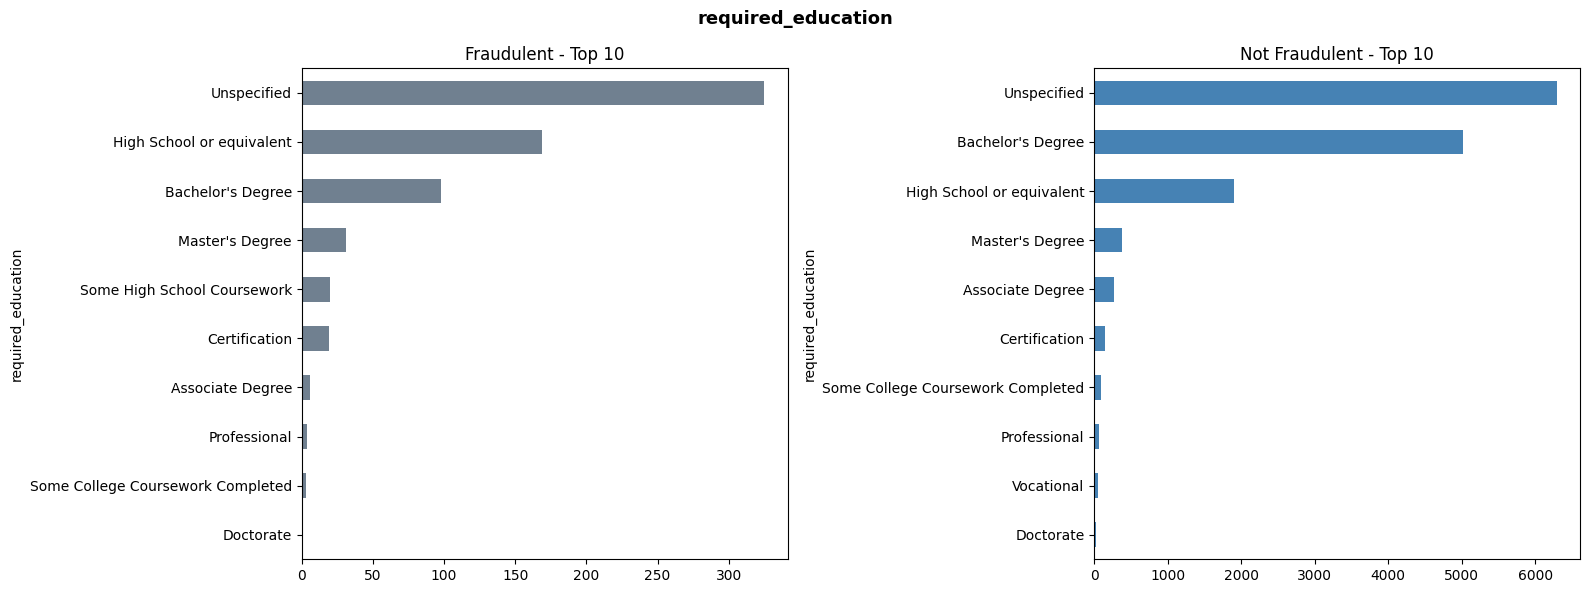

In [21]:
compare_fradulent_vs_not(df, 'required_education')

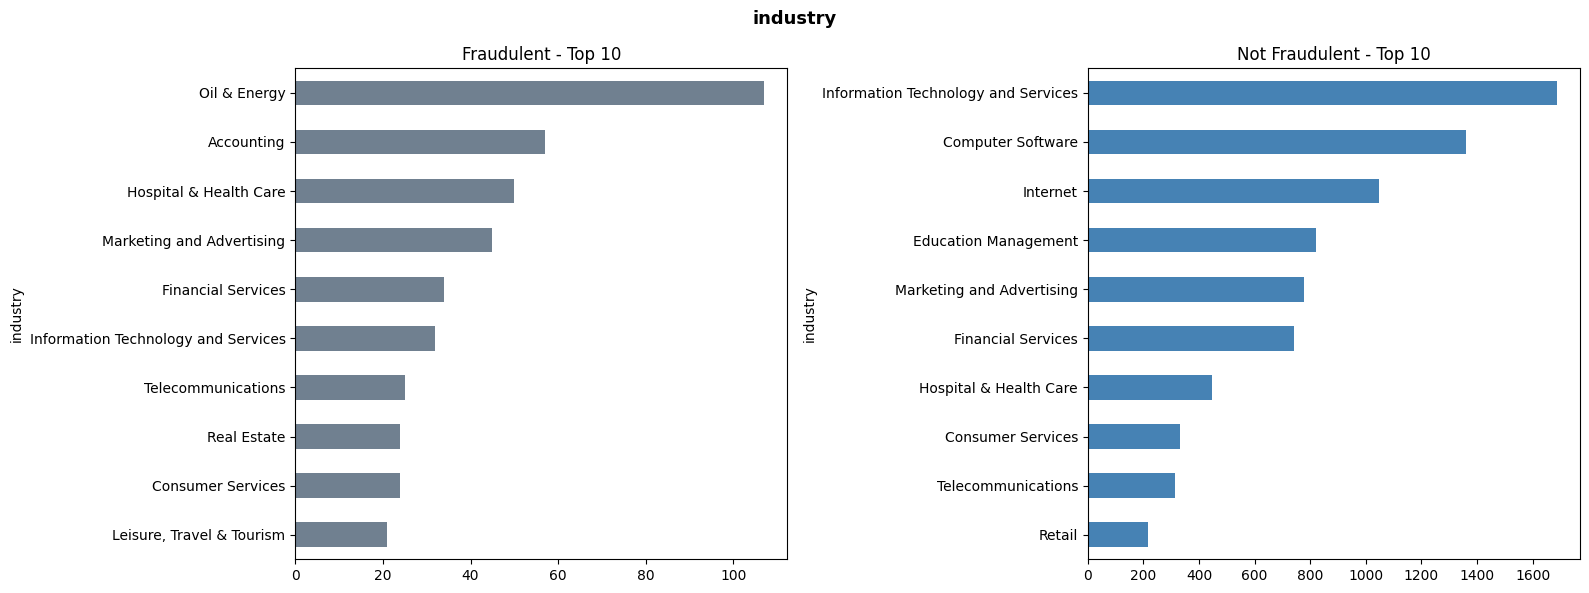

In [22]:
compare_fradulent_vs_not(df, 'industry')

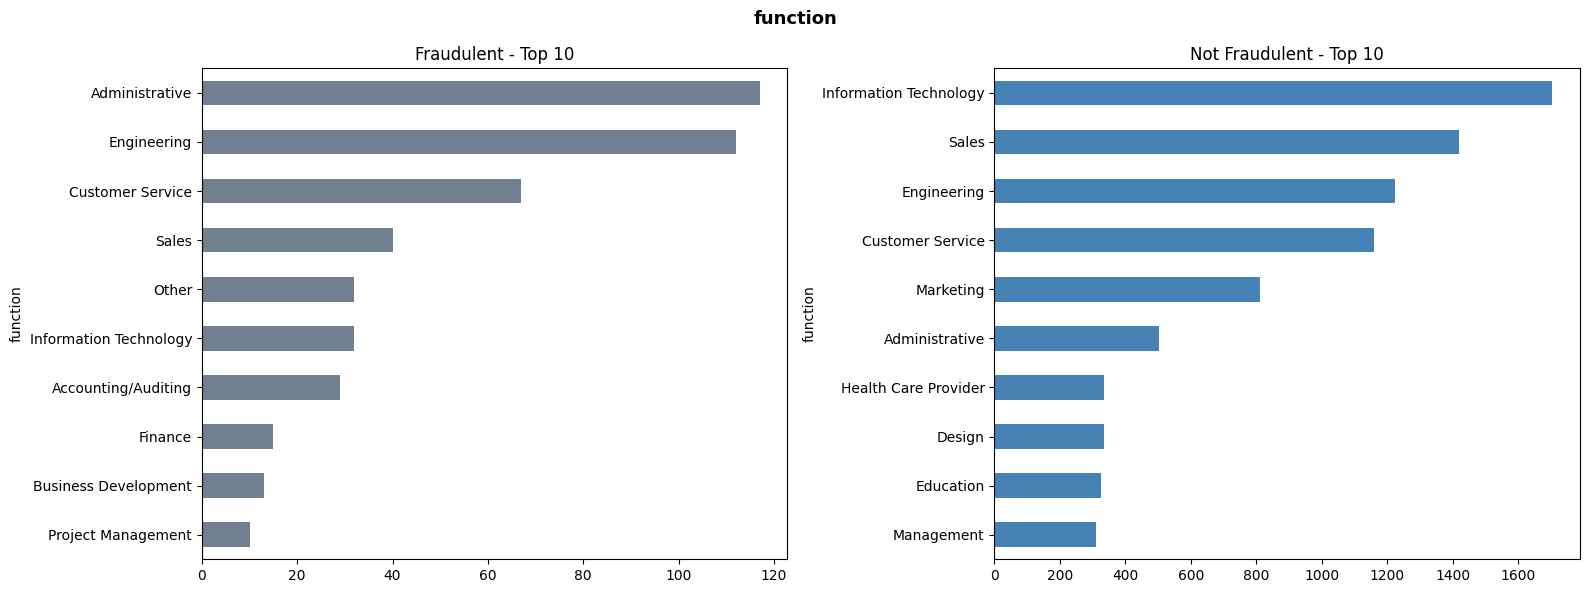

In [23]:
compare_fradulent_vs_not(df, 'function')

In [24]:
# encode categorical columns with 't' and 'f'
for col in ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']:
    df[col] = (df[col] == 't').astype(int)

# encode industry and function
for col in ['industry', 'function']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    mapping = pd.DataFrame({'label': le.classes_, 'encoded': le.transform(le.classes_)})
    print(f"\n{col}:")
    print(mapping)


industry:
                              label  encoded
0                        Accounting        0
1                 Airlines/Aviation        1
2    Alternative Dispute Resolution        2
3                         Animation        3
4                 Apparel & Fashion        4
..                              ...      ...
127                       Wholesale      127
128                Wine and Spirits      128
129                        Wireless      129
130             Writing and Editing      130
131                             NaN      131

[132 rows x 2 columns]

function:
                     label  encoded
0      Accounting/Auditing        0
1           Administrative        1
2              Advertising        2
3             Art/Creative        3
4         Business Analyst        4
5     Business Development        5
6               Consulting        6
7         Customer Service        7
8             Data Analyst        8
9                   Design        9
10            Dist

In [25]:
# Check cardinalities of labels in each categorical column
df.select_dtypes(include='object').nunique().sort_values()

/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_97225/303663278.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique().sort_values()


employment_type            5
required_experience        7
required_education        13
country                   83
salary_range             858
company_profile         1535
benefits                5524
title                   9266
requirements           10313
description            12515
dtype: int64

In [26]:
# One-hot encoding for categorical columns where the cardinalities of the labels are low, except for binary columns

df = pd.get_dummies(df, columns=['employment_type', 'required_experience', 'required_education', 'country'])

In [27]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [28]:
salary_features = pd.DataFrame({
    'salary_min': df['salary_range'].str.extract(r'(\d+)-')[0].astype(float).fillna(0),
    'salary_max': df['salary_range'].str.extract(r'-(\d+)')[0].astype(float).fillna(0),
    'has_salary': df['salary_range'].apply(lambda x: 0 if str(x) in ['Unknown', 'nan'] else 1)
})
salary_features['salary_mid'] = (salary_features['salary_min'] + salary_features['salary_max']) / 2

df = pd.concat([df.drop(columns=['salary_range']), salary_features], axis=1)

In [29]:
df.head() # What we have so far

,title,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,industry,function,...,country_UG,country_US,country_VI,country_VN,country_ZA,country_ZM,salary_min,salary_max,has_salary,salary_mid
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a ...,nan,0,1,0,131,22,...,0,1,0,0,0,0,0.0,0.0,0,0.0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you: Your key responsibili...,What you will get from us Through being part o...,0,1,0,75,7,...,0,0,0,0,0,0,0.0,0.0,0,0.0
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, bu...",Our culture is anything but corporate—we have ...,0,1,0,22,31,...,0,1,0,0,0,0,0.0,0.0,0,0.0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review Manager LOCATION...,QUALIFICATIONS: RN license in the State of Te...,Full Benefits Offered,0,1,1,51,16,...,0,1,0,0,0,0,0.0,0.0,0,0.0
6,Head of Content (m/f),"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-s...,Your Know-How: ...,Your Benefits: Being part of a fast-growing...,0,1,1,89,20,...,0,0,0,0,0,0,20000.0,28000.0,1,24000.0


## Making sense of the columns title, company_profile, description, requirements and benefits


In [30]:
info_df = df[['title', 'company_profile', 'description', 'requirements', 'benefits']].copy()
df = df.drop(columns=['title', 'company_profile', 'description', 'requirements', 'benefits'])

In [31]:
print(info_df['description'].str.len())
print(sum(info_df['requirements']=='nan'))
print(sum(info_df['company_profile']=='nan'))

0         910
1        2077
3        2622
4        1541
6         441
         ... 
17875    1440
17876    1221
17877    1312
17878     506
17879    1883
Name: description, Length: 14939, dtype: int64
1779
2426


In [32]:

info_df['company_profile'].str.split().str.len().fillna(0)

0        144
1        157
3         86
4        211
6        135
        ... 
17875    297
17876    337
17877     32
17878      1
17879    297
Name: company_profile, Length: 14939, dtype: int64

In [33]:
info_df['company_profile'].unique()

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             'We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place. We have a 

In [34]:
info_df['description'].unique()

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [35]:
classifier = pipeline('zero-shot-classification', model='cross-encoder/nli-MiniLM2-L6-H768', device=0)

def is_legitimate(text):
    if str(text) == 'nan':
        return 0
    result = classifier(str(text)[:512], candidate_labels=['legitimate company', 'fraudulent company'])
    return result['scores'][0]  # confidence it's legitimate

info_df['company_profile_legitimacy_score'] = info_df['company_profile'].apply(is_legitimate)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 11561.23it/s]
RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
def is_legitimate(text):
    result = classifier(str(text)[:512], candidate_labels=['legitimate job title', 'fake or suspicious job title'])
    return result['scores'][0]  # confidence it's legitimate

info_df['title_legitimacy_score'] = info_df['title'].apply(is_legitimate)

In [37]:
def believability_score(text):
    if str(text) == 'nan':
        return 0
    result = classifier(str(text)[:512], candidate_labels=['legitimate job posting', 'fraudulent job posting'])
    return result['scores'][0]  # confidence it's legitimate

info_df['description_believability'] = info_df['description'].apply(believability_score)

For requirements and benefits columns, we will test this idea

Idea: 
Since requirements, benefits are written in phrases/bullet points -> sentence_transformers + kmeans clustering to see groupings

To test my claim,
we will use sentence_transformers + kmeans on requirements

In [38]:
# Check semantic similarity of requirements column
model = SentenceTransformer('all-MiniLM-L6-v2')
phrases = info_df['requirements'].dropna().tolist()
embeddings = model.encode(phrases)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10213.08it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


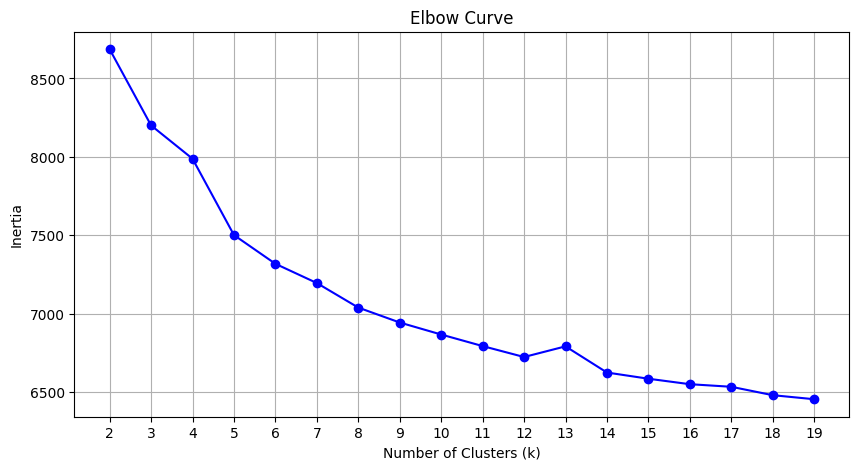

In [39]:
# Preparing kmeans model for clustering requirements

# Finding best k

inertias = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.xticks(k_range)
plt.grid(True)
plt.show()

/Users/zhengchong/Desktop/GovTech THA/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/zhengchong/Desktop/GovTech THA/.venv/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/zhengchong/Desktop/GovTech THA/.venv/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/zhengchong/Desktop/GovTech THA/.venv/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. 

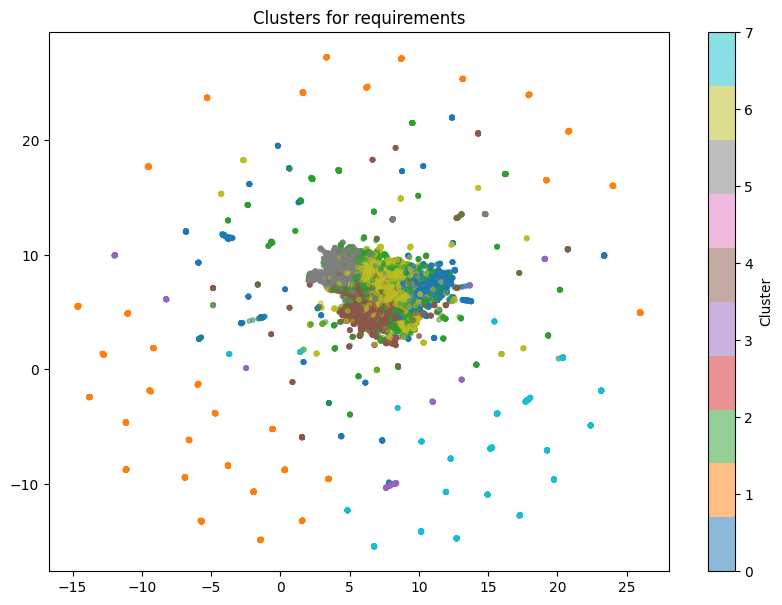

In [40]:
# k = 8 is chosen as there is a significant dip in inertia

kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(embeddings)

# reduce to 2D for plotting
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
reduced = reducer.fit_transform(embeddings)

# plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('Clusters for requirements')
plt.show()

No obvious clusters. So, we might reconsider this approach. Will just stick with using the NLI model


In [41]:
def is_reasonable(text):
    if str(text).strip() == '' or str(text) == 'nan':
        return 0
    result = classifier(str(text)[:512], candidate_labels=['reasonable requirements', 'ridiculous requirements'])
    return result['scores'][0]  # confidence it's legitimate

info_df['requirements_reasonable_score'] = info_df['requirements'].apply(is_reasonable)

In [42]:
def is_real(text):
    if str(text) == 'nan':
        return 0
    result = classifier(str(text)[:512], candidate_labels=['standard professional employee benefits', 'vague exaggerated or unrealistic benefits designed to lure victims'])
    return result['scores'][0]  # confidence it's legitimate

info_df['benefits_legitimacy_score'] = info_df['benefits'].apply(is_real)

In [43]:
df = pd.concat([df, info_df.loc[:, 'company_profile_legitimacy_score':]], axis=1)

In [44]:
df.head() # Cleaned dataset

,telecommuting,has_company_logo,has_questions,industry,function,fraudulent,employment_type_Contract,employment_type_Full-time,employment_type_Other,employment_type_Part-time,...,country_ZM,salary_min,salary_max,has_salary,salary_mid,company_profile_legitimacy_score,title_legitimacy_score,description_believability,requirements_reasonable_score,benefits_legitimacy_score
0,0,1,0,131,22,0,0,0,1,0,...,0,0.0,0.0,0,0.0,0.950475,0.647323,0.907094,0.854154,0.000000
1,0,1,0,75,7,0,0,1,0,0,...,0,0.0,0.0,0,0.0,0.900273,0.790123,0.912345,0.831448,0.786973
3,0,1,0,22,31,0,0,1,0,0,...,0,0.0,0.0,0,0.0,0.832427,0.807011,0.822901,0.798754,0.824886
4,0,1,1,51,16,0,0,1,0,0,...,0,0.0,0.0,0,0.0,0.935890,0.574538,0.896759,0.662999,0.757958
6,0,1,1,89,20,0,0,1,0,0,...,0,20000.0,28000.0,1,24000.0,0.914054,0.802815,0.923787,0.920975,0.951247


## Training classification models

For our classification models, we will consider a few models and evaluate them to see which model gives the best results.
Such models include:
- Random Forest
- XGBoost
- Logistic Regression

Some reasons for choosing these models:
- Can handle high dimensional data/many columns
- Can handle large datasets

Our evaluation metrics:
- Recall Score
- F1 Score
- AUR-ROC

In [45]:
# 80:20 train:test split
X = df.copy().drop(columns='fraudulent')
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
# Scaling data for logistic regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost':       XGBClassifier(scale_pos_weight=scale, random_state=42, eval_metric='logloss'),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=5000, solver='saga', random_state=42),
}

By keeping class_weight balanced for all three models, we compensate for imbalance in the cleaned dataset(Recall that most of the rows are not fraudulent)

Random Forest:
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      2853
  Fraudulent       0.96      0.56      0.71       135

    accuracy                           0.98      2988
   macro avg       0.97      0.78      0.85      2988
weighted avg       0.98      0.98      0.98      2988

XGBoost:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      2853
  Fraudulent       0.78      0.80      0.79       135

    accuracy                           0.98      2988
   macro avg       0.89      0.89      0.89      2988
weighted avg       0.98      0.98      0.98      2988

Logistic Regression:
              precision    recall  f1-score   support

  Legitimate       0.99      0.84      0.91      2853
  Fraudulent       0.19      0.76      0.30       135

    accuracy                           0.84      2988
   macro avg       0.59      0.80      0.60      2988
weighted avg       0.95      

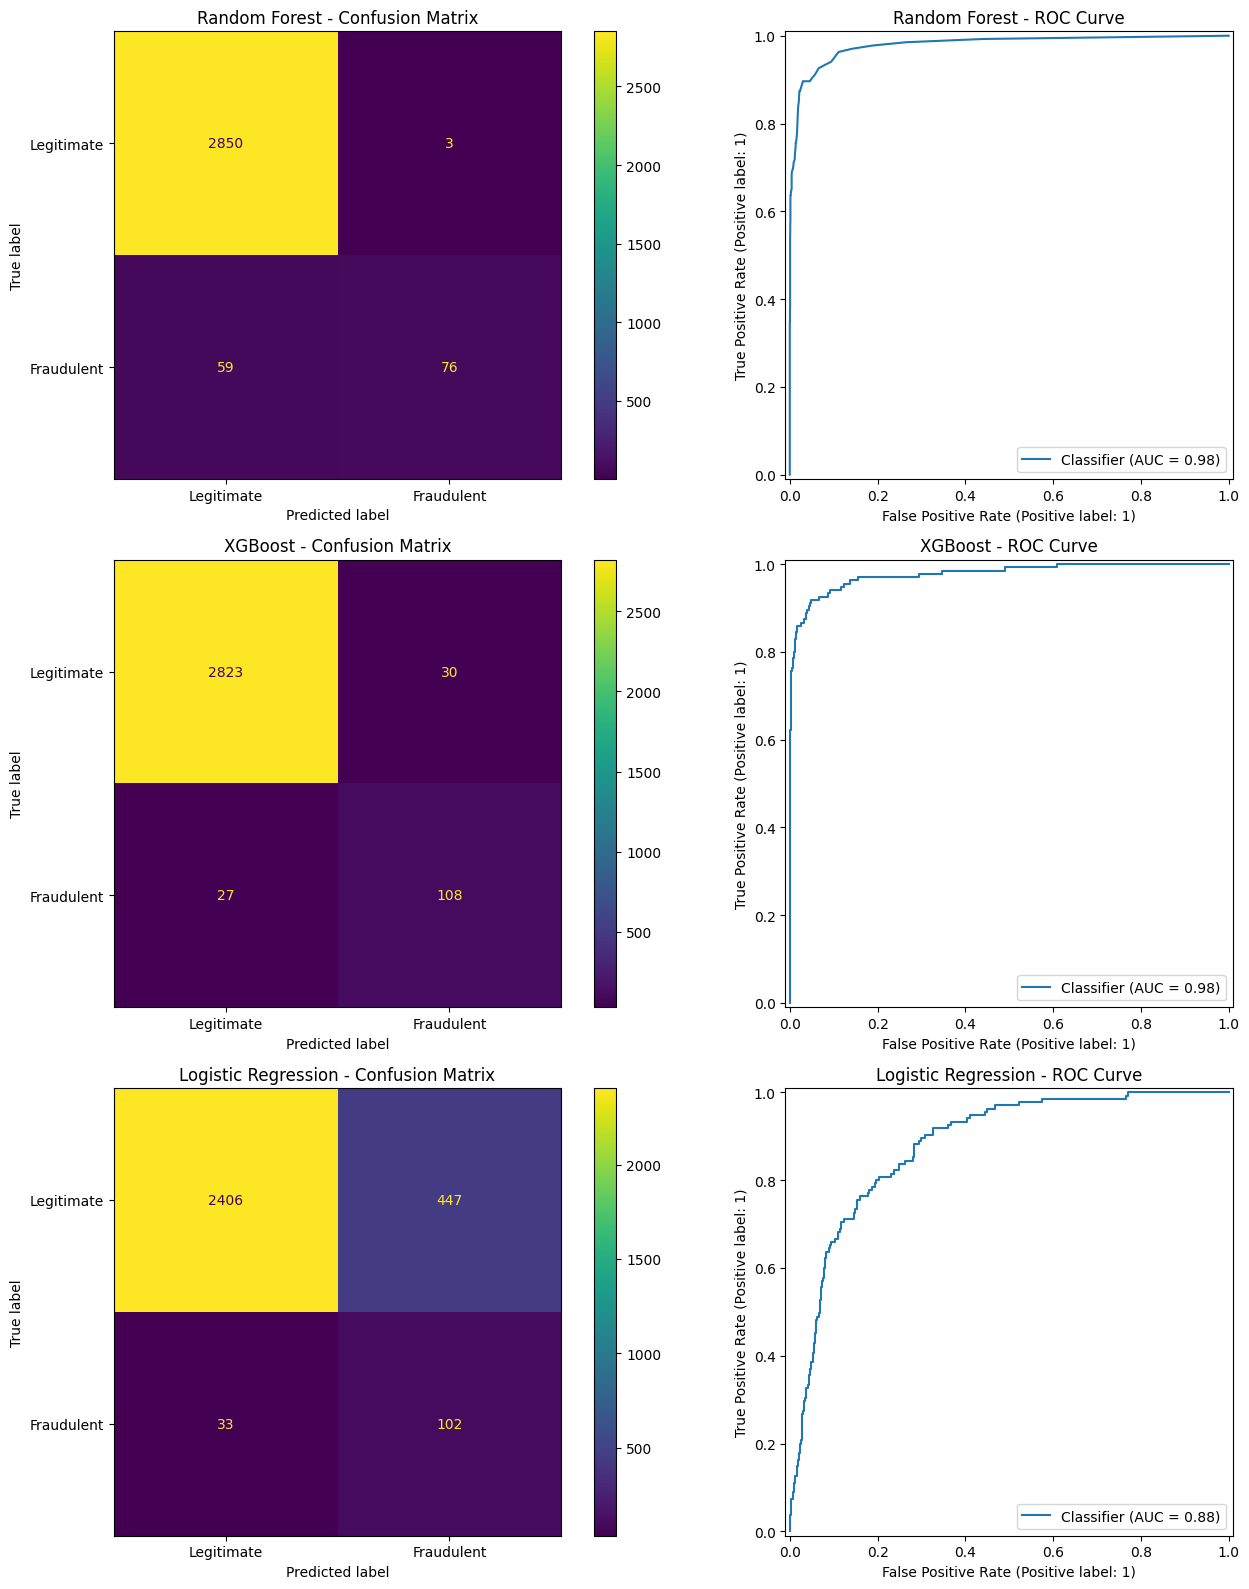

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

for i, (name, model) in enumerate(models.items()):
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    print(f"{name}:")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                            display_labels=['Legitimate', 'Fraudulent'],
                                            ax=axes[i][0])
    axes[i][0].set_title(f'{name} - Confusion Matrix')

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[i][1])
    axes[i][1].set_title(f'{name} - ROC Curve')

plt.tight_layout()
plt.show()

Summary

Recall (Fraudulent):
- Random Forest: 0.56
- XGBoost: 0.80
- Logistic Regression: 0.76

F1-Score (Fraudulent):
- Random Forest: 0.71
- XGBoost: 0.79
- Logistic Regression: 0.30

AUC-ROC:
- Random Forest: 0.98
- XGBoost: 0.98
- Logistic Regression: 0.88

**Overall verdict:**

XGBoost is the recommended model for this fraud detection task. It achieves the highest AUC of 0.98, indicating near-perfect ability to distinguish fraudulent from legitimate jobs across all thresholds. It also achieves the best recall of 0.80 and the highest F1-score of 0.79 among all three models. Random Forest matches XGBoost on AUC but significantly underperforms on recall (0.56) and F1 (0.71), missing nearly half of all fraudulent jobs. Logistic Regression performs poorly on this larger imbalanced dataset, despite a reasonable recall of 0.76, its F1-score of 0.30 indicates very low precision, meaning it generates excessive false alarms. XGBoost remains the strongest and most balanced model overall.



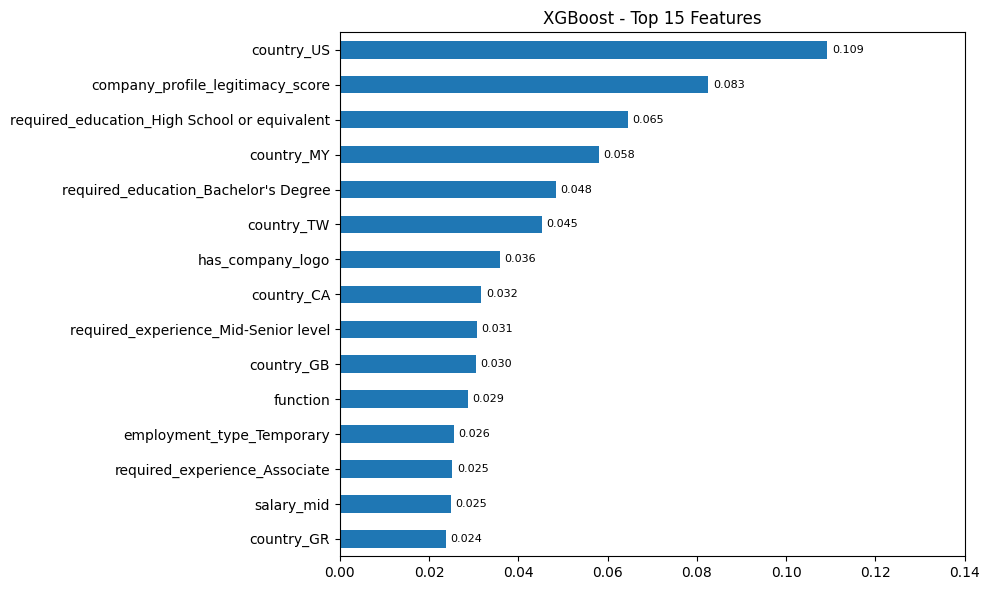

In [49]:
# feature importance
importances = pd.Series(models['XGBoost'].feature_importances_, index=X.columns)
top_features = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top_features.plot(kind='barh', ax=ax)

for bar, val in zip(ax.patches, top_features):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=8)

plt.xlim(0, 0.14)
plt.title('XGBoost - Top 15 Features')
plt.tight_layout()
plt.show()